# **Redes Neuronales Superficiales - Red de Hopfield**

---

## Información del curso
* **Curso:** Redes neuronales 2019781
* **Profesor:** Luis Fernando Niño Vasquez
* **Semestre:** 2026-1

## Miembros del equipo

| Nombre | Correo |
| :--- | :--- |
| **David Felipe Marin Rosas** | dmarinro@unal.edu.co |
| **Laura Camila Girón Pinto** | lgironp@unal.edu.co |
| **Nicolas Martinez Lopez** | nmartinezl@unal.edu.co |
| **Diego Esteban Morales Granados** |dimorales@unal.edu.co|
| **Sergio Ivan Motta Doncel** | smottad@unal.edu.co |


# **Librerías a Utilizar**



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
from sklearn.datasets import fetch_openml
from ipywidgets import interact, widgets

# **Redes de Hopfield Clásicas**

## Definición y Evolución Histórica

Una **Red de Hopfield** es una red neuronal recurrente (RNNs) que funciona como un sistema de memoria asociativa con unidades binarias.
Si se le proporciona un patrón incompleto o ruidoso, el sistema realiza un proceso para converger a un mínimo local recuperando el estado original. Es similar al cerebro humano reconociendo una canción completa tras escuchar solo tres nota, el estímulo parcial "evoca" el recuerdo completo.


### Breve Contexto Histórico
* **Origen (1982):** Formalizada por **John Hopfield**, demostrando capacidades computacionales emergentes en sistemas de unidades simples, una inspiración son los Modelos de Ising de la física estadística (sistemas de espines magnéticos buscando equilibrio).
* **Premio Nobel de Física 2024:** John Hopfield y Geoffrey Hinton ganaron el premio nobel de física por descubrimientos fundamentales para el aprendizaje automático con redes neuronales artificiales

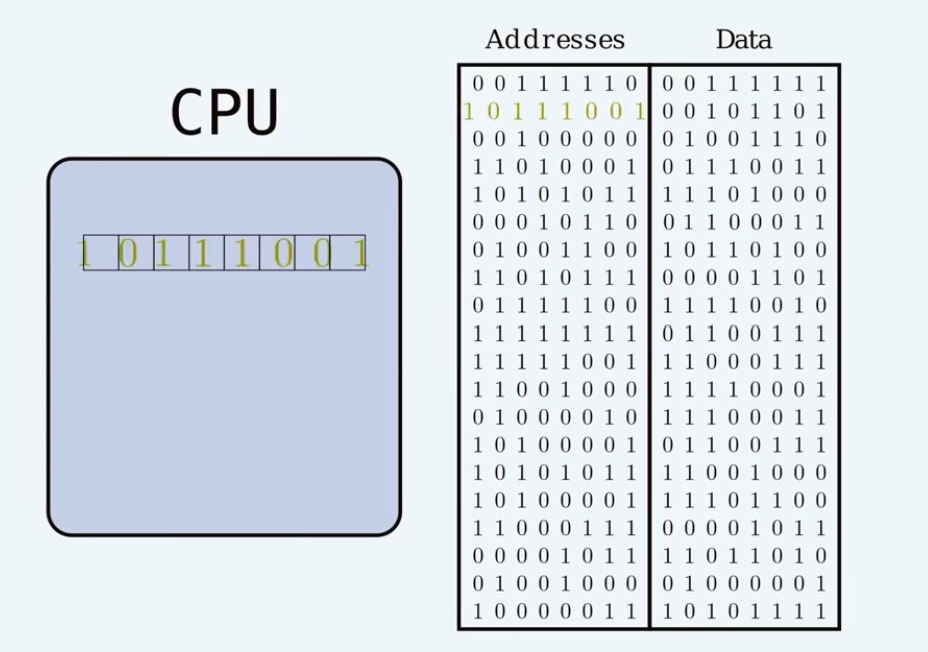

In [2]:
# @title Test { display-mode: "form" }
from IPython.display import HTML

video_id = 'oWBf9hfW_4Y'
inicio = 6.45
duracion = 1.62

audio_limpio_html = f"""
<div style="background: #f4f4f4; padding: 20px; border-radius: 15px; text-align: center; border: 1px solid #ccc;">
    <p style="font-family: sans-serif; color: #333;"><strong>Test de Memoria Asociativa</strong></p>
    <p style="font-size: 12px; color: #666;">El audio se detendrá automáticamente tras {duracion} segundos.</p>

    <div id="player"></div>

    <button onclick="playSnippet()" style="padding: 10px 25px; background: #e67e22; color: white; border: none; border-radius: 20px; cursor: pointer; font-weight: bold;">
        ▶️ Escuchar Estímulo
    </button>
</div>

<script>
  var tag = document.createElement('script');
  tag.src = "https://www.youtube.com/iframe_api";
  var firstScriptTag = document.getElementsByTagName('script')[0];
  firstScriptTag.parentNode.insertBefore(tag, firstScriptTag);

  var player;
  function onYouTubeIframeAPIReady() {{
    player = new YT.Player('player', {{
      height: '0',
      width: '0',
      videoId: '{video_id}',
      playerVars: {{ 'start': {inicio}, 'controls': 0, 'disablekb': 1 }}
    }});
  }}

  function playSnippet() {{
    player.seekTo({inicio});
    player.playVideo();
    setTimeout(function() {{
      player.pauseVideo();
    }}, {duracion} * 1000); // Se detiene automáticamente
  }}
</script>
"""

display(HTML(audio_limpio_html))

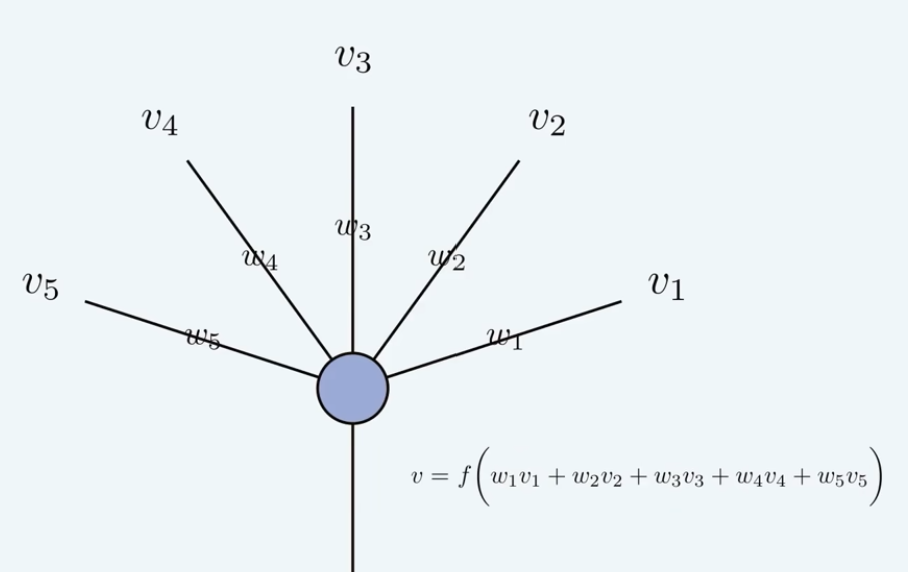

### La Función de Energía
Para un sistema con conexiones simétricas ($w_{ij} = w_{ji}$) y sin autoconexiones ($w_{ii} = 0$), la energía se define como:

$$E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j + \sum_i \theta_i s_i$$


* **$w_{ij}$**: Es el peso o fuerza de conexión entre la neurona $i$ y la $j$.
* **$s_i$ y $s_j$**: Son los estados actuales (+1 o -1) de esas dos neuronas.
* **$\theta_i$ (Theta)**: Es el **umbral** o *bias* de la neurona $i$.

Si dos neuronas $i$ y $j$ tienen un peso positivo ($w_{ij} > 0$) y ambas están en el mismo estado, el producto es positivo. El signo negativo al inicio hace que esa armonía reste energía, estabilizando el sistema.


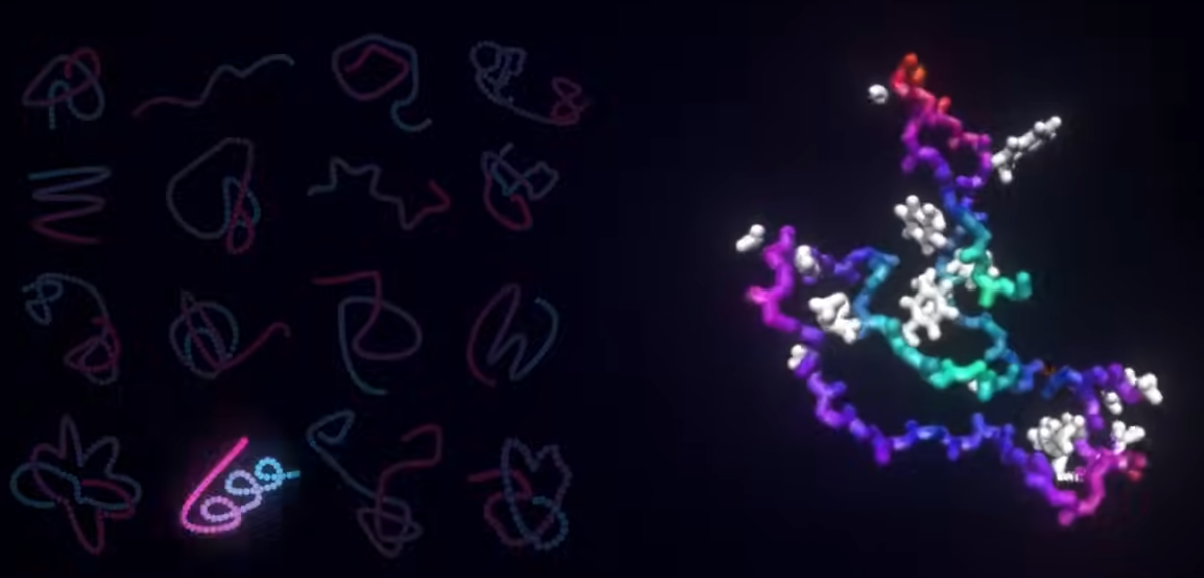

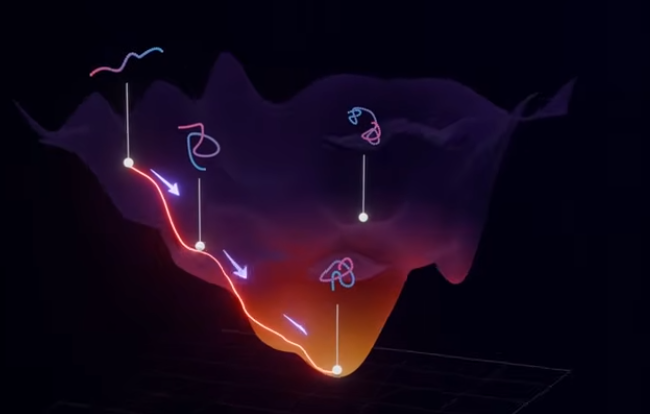

## Teoría Hebbiana: El Mecanismo de Aprendizaje


* **Regla de Hebb:** *"Neurons that fire together, wire together"*. Los pesos se graban como el producto de los estados:



Para almacenar recuerdos, se ajustan los pesos de modo que los patrones deseados se conviertan en los **puntos de energía más bajos**

Matemáticamente, el peso entre dos neuronas se define como el promedio del producto de sus estados a través de todos los patrones de entrenamiento. Para almacenar un conjunto de $P$ patrones $\xi^\mu$, los pesos de las conexiones se calculan como:


$$w_{ij} = \frac{1}{P} \sum_{\mu=1}^{P} \xi_i^\mu \xi_j^\mu$$

#### **¿Qué significa cada componente?**
* **$w_{ij}$**: Es la fuerza (peso) de la conexión entre la neurona $i$ y la neurona $j$.
* **$P$**: Cantidad de patrones (recuerdos) a guardar.
* **$\xi_i^\mu$**: El estado ($+1$ o $-1$) de la neurona $i$ en el patrón $\mu$.


**Simetría vs. Biología:**  Conexiones asimétricas ($w_{ij} \neq w_{ji}$), lo que genera caos.
  * **Hopfield:** Conexiones **simétricas** ($w_{ij} = w_{ji}$).
  * **¿Por qué?** La simetría garantiza que la red siempre se detenga en un recuerdo y no oscile infinitamente.

**¿Cómo se aplica a el modelo?**
Este ajuste de pesos "fuerza" a la red a que los patrones deseados sean estados de baja energía. Si dos neuronas coinciden frecuentemente en los datos de entrenamiento, su peso $w_{ij}$ será alto, haciendo que el sistema "prefiera" que ambas estén en el mismo estado.

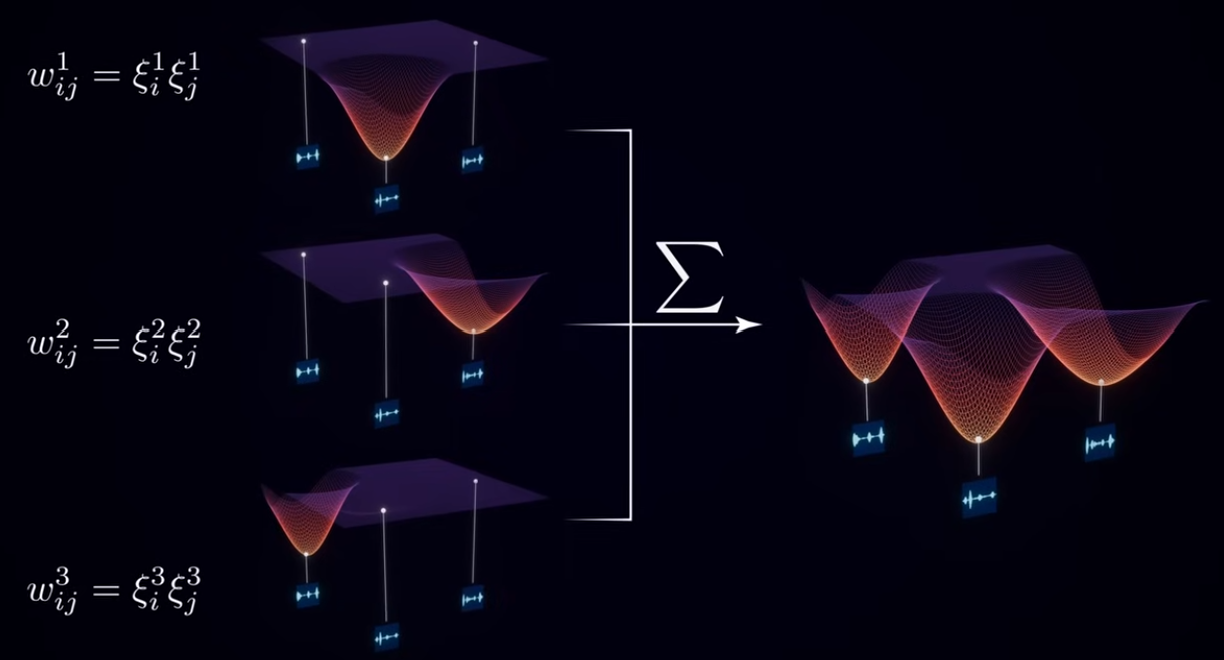

## Ventajas, desventajas y limitaciones del modelo clásico.

| Categoría | Ventajas | Desventajas | Limitaciones frente a ML moderno|
| :--- | :--- | :--- | :--- |
| Funcionamiento y dinámica. | Memoria asociativa: reconoce y <br>corrige patrones ruidosos [5]. | Aparición de estados espurios <br>al saturarse [10]. | Converge a mínimos locales, no al <br>óptimo global [12]. |
| Fundamento teórico. | Función de energía global <br>garantiza convergencia [5][8]<br>[9][10]. | No distingue un patrón de <br>su inverso [10]. | Solo captura correlaciones entre <br>pares de variables [10]. |
| Capacidad de almacenamiento. | - | Límite de ~14% de memorias <br>respecto al número de <br>neuronas [10]. | - |
| Aprendizaje y entrenamiento. | Regla hebbiana: aprendizaje <br>directo, sin gradiente [5][10]. |  | Estados binarios no diferenciables, <br>incompatibles con deep learning [5][10]. |

Una de las principales ventajas del modelo de Hopfield es su capacidad de funcionar como una memoria asociativa direccionable por contenido (*content-addressable memory*), que confiere al modelo la capacidad de reconocimiento de patrones y corrección de errores. Para recuperar los patrones almacenados a partir de versiones parciales o ruidosas de los mismos, la dinámica iterativa del sistema conduce al estado estable más cercano en el espacio de configuraciones, permitiendo reconstruirlo [5]. Adicional a esto, la dinámica de la red sea dominada por la función de energía global, ya que esta garantiza que el sistema converja hacia un estado estable al disminuir o permanecer constante [5][8]. Esto permite analizar el comportamiento colectivo del modelo, la dinámica de la red y la estabilidad de los patrones almacenados mediante herramientas de la mecánica estadística, lo que le otorga peso teórico a su funcionamiento [9][10]. Finalmente, el proceso de aprendizaje del modelo es computacionalmente simple e inmediato debido a que los patrones se almacenan en la matriz de pesos mediante una regla hebbiana basada en el producto externo entre vectores de activación, lo que permite incorporar nuevos patrones de forma directa, sin necesidad de algoritmos iterativos de entrenamiento ni optimización por gradiente [5][10].

A pesar de las ventajas presentadas, estas redes presentan múltiples desventajas y limitaciones que llevaron al desarrollo de las redes de Hopfield modernas. Entre estas se tienen en cuenta que las redes de Hopfield clásicas tienen una capacidad de almacenamiento limitada, que escala linealmente por número de neuronas, y estudios como el de Amit, Gutfreund y Sompolinsky en 1985, o el de Folli, Leonetti y Ruocco en el 2017, demostraron que la recuperación fiable de patrones solo se mantiene mientras el número de memorias almacenadas sea inferior a aproximadamente el 14% del número total de neuronas. Cuando este umbral se supera, la probabilidad de errores en la recuperación aumenta rápidamente y la red deja de funcionar de forma fiable como memoria asociativa. Gracias a esto, en el modelo pueden aparecer configuraciones estables que no corresponden a ninguno de los patrones almacenados originalmente, combinando memorias previamente almacenadas y aumentando su frecuencia a medida que aumenta la carga de almacenamiento en la red [10].

Otra de las desventajas es que, debido a la forma en que los patrones se almacenan mediante la regla de aprendizaje hebbiano, la red no distingue entre un patrón y su versión invertida. Es decir, si un patrón almacenado está representado por un vector de activaciones formado por valores +1 y -1, el mismo conjunto de pesos también hace estable el patrón opuesto, en el que todos los signos están invertidos. Por ejemplo, si el estado (+1, -1, +1, -1) es un atractor de la dinámica de la red, el estado (-1, +1, -1, +1) puede serlo también. Consecuencia de ello, cada patrón almacenado genera dos estados estables posibles: el patrón original y su inverso, lo que llevaría a la red aconverger hacia cualquiera de los dos estados y reducir la capacidad efectiva del sistema para representar patrones distintos [10].

Más allá de estas desventajas inherentes al modelo, las redes de Hopfield clásicas presentan limitaciones desde la perspectiva del aprendizaje automático contemporáneo, que suelen basarse en aprendizaje profundo basado en gradiente, donde la función debe ser diferenciable. En su formulación original, las neuronas adoptan estados binarios (+1, -1) y la dinámica del sistema se define mediante funciones de activación discretas, que no pueden ser derivadas [5][10]. Además, la regla hebbiana en la que se basa captura correlaciones entre dos variables, no relaciones no lineales más complejas o de muchos elementos simultáneamente [10]. Finalmente, cuando las redes de Hopfield se emplean como herramientas de optimización combinatoria, la dinámica del sistema tiende a converger hacia mínimos locales de la función de energía. Aunque estos estados representan soluciones válidas del problema formulado, no existe garantía de que correspondan al óptimo global. En consecuencia, la calidad de las soluciones obtenidas depende fuertemente de la formulación del problema y de la elección de los parámetros del modelo [12].

# **Redes de Hopfield Modernas**

Las redes de Hopfield modernas, también conocidas como "Modern Hopfield Networks" (MHN) o "Dense Associative Memories" (DAM), son una evolución de las redes de Hopfield clásicas. Representan un tipo de memoria asociativa densa que permite almacenar y recuperar un número exponencial de patrones en comparación con las versiones originales. En esencia, son modelos de redes neuronales recurrentes que utilizan funciones de energía polinómicas de alto grado para mejorar la capacidad de almacenamiento y la robustez al ruido.

A diferencia de las redes clásicas (que se basan en una energía cuadrática y almacenan hasta aproximadamente $0.14N$ patrones, donde N es el número de neuronas), las modernas emplean interacciones de orden superior (polinomios de grado p > 2) para lograr una capacidad de almacenamiento que crece como $2^{N^{1-\frac{1}{p}}}$, permitiendo manejar conjuntos de datos mucho más grandes. Esto las hace útiles en aplicaciones modernas como el aprendizaje profundo, donde se integran en arquitecturas como transformers para tareas de atención y recuperación de información.

Estas redes mantienen el principio de minimización de energía para converger a estados estables (patrones memorizados), pero con una mayor densidad de memorias, lo que las hace ideales para problemas de optimización combinatoria, procesamiento de lenguaje natural y visión por computadora.

En las redes de Hopfield clásicas, la función de energía es cuadrática (grado 2): solo considera interacciones de pares de neuronas. Esto limita la capacidad porque los "pozos" de energía (los atractores que representan memorias) no son lo suficientemente profundos ni numerosos cuando hay muchos patrones.
Las redes modernas reemplazan esta energía cuadrática por una función polinómica de grado superior (p > 2, típicamente p = 3, 4 o más). Un polinomio es simplemente una expresión matemática de la forma:
$$F(z) = z^p \quad \text{o} \quad F(z) = \max(z, 0)^p$$
(donde $  z  $ es la similitud o solapamiento entre el estado actual de la red y un patrón memorizado, calculado como el producto punto normalizado).
La energía total entonces se escribe como:
$$E(\xi) = -\sum_{\mu=1}^{M} F\left( \frac{1}{N} \xi \cdot \mu^{(\mu)} \right) = -\sum_{\mu=1}^{M} \left( \frac{1}{N} \xi \cdot \mu^{(\mu)} \right)^p$$


*   **$E(\xi)$**: Representa la **Función de Energía** del sistema para un estado dado $\xi$. El objetivo de la red es minimizar esta energía.
*   **$\xi$**: Es el **estado actual de la red**, un vector que representa las activaciones de todas las neuronas en un momento dado. Puede contener valores binarios (+1 o -1) o continuos (en versiones modernas).
*   **$\sum_{\mu=1}^{M}$**: Indica una **sumatoria** sobre todos los patrones memorizados. $\mu$ es el índice de un patrón específico, y $M$ es el número total de patrones almacenados en la red.
*   **$F(...)$**: Es la **función de activación no lineal** o función de energía polinómica. Transforma la similitud entre el estado actual y un patrón memorizado. En el caso específico de la ecuación proporcionada, $F(x) = x^p$.
*   **$N$**: Es el **número total de neuronas** en la red.
*   **$\mu^{(\mu)}$**: Representa el **patrón memorizado** número $\mu$. Es un vector de activaciones que la red ha aprendido a reconocer.
*   **$\xi \cdot \mu^{(\mu)}$**: Es el **producto punto** entre el estado actual de la red $\xi$ y el patrón memorizado $\mu^{(\mu)}$. Mide la similitud o superposición entre el estado de la red y ese patrón específico. Un valor alto indica una gran similitud.
*   **$\frac{1}{N} \xi \cdot \mu^{(\mu)}$**: Es la **similitud normalizada**. Al dividir el producto punto por el número de neuronas ($N$), se obtiene un valor entre -1 y 1 que representa el porcentaje de coincidencia entre el estado actual y el patrón memorizado. Esta normalización es crucial para la estabilidad numérica y el comportamiento de la red.
*   **$p$**: Es el **grado del polinomio** en la función de energía. Para las redes de Hopfield clásicas, $p=2$. Para las redes de Hopfield modernas, $p > 2$ (típicamente 3, 4 o más) para aumentar la capacidad de almacenamiento y la robustez.


**¿Por qué polinomios de grado alto?**

Un término de grado p introduce interacciones de orden superior (de p neuronas a la vez), en lugar de solo pares.
Matemáticamente, elevar a una potencia alta hace que la función crezca muy rápido cuando la similitud es cercana a 1 (es decir, cuando el estado está muy parecido a un patrón memorizado).
Esto crea pozos de energía muy profundos y estrechos alrededor de cada memoria verdadera, mientras que los estados espurios (mezclas indeseadas de patrones) quedan en valores de energía mucho más altos.
Como resultado, la dinámica de minimización de energía converge con mucha mayor precisión y robustez hacia los patrones correctos, incluso con ruido o con un número muy grande de memorias almacenadas.

/tmp/ipykernel_2620/4257957373.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


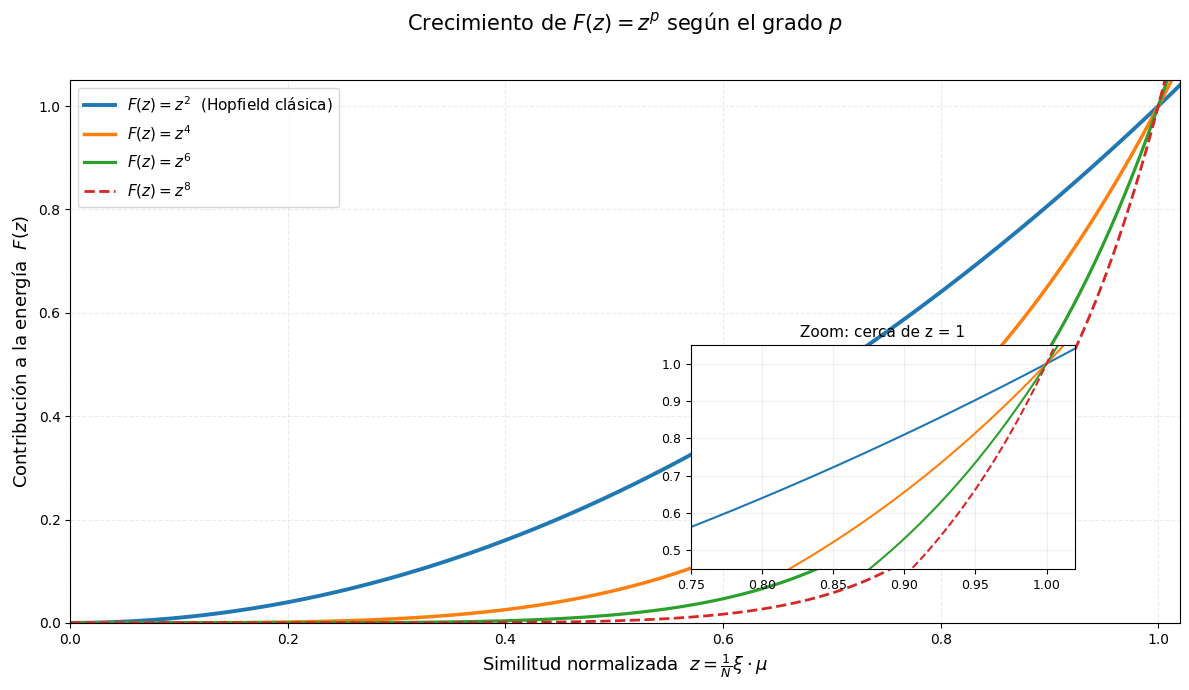

In [3]:
# -------------------------------------------------------
# 1. Curvas
# -------------------------------------------------------
z = np.linspace(0, 1.02, 600)

f2 = z ** 2                     # clásica (grado 2)
f4 = z ** 4
f6 = z ** 6
f8 = z ** 8

# -------------------------------------------------------
# 2. Figura principal
# -------------------------------------------------------
plt.figure(figsize=(12, 7))

plt.plot(z, f2, label=r'$F(z) = z^2$  (Hopfield clásica)',
         linewidth=2.8, color='#1f77b4')
plt.plot(z, f4, label=r'$F(z) = z^4$',
         linewidth=2.5, color='#ff7f0e')
plt.plot(z, f6, label=r'$F(z) = z^6$',
         linewidth=2.3, color='#2ca02c')
plt.plot(z, f8, label=r'$F(z) = z^8$',
         linewidth=2.0, color='#d62728', linestyle='--')

# Estilo
plt.title('Crecimiento de $F(z) = z^p$ según el grado $p$\n',
          fontsize=15, pad=18)
plt.xlabel('Similitud normalizada  $z = \\frac{1}{N} \\xi \\cdot \\mu$', fontsize=13)
plt.ylabel('Contribución a la energía  $F(z)$', fontsize=13)

plt.grid(True, alpha=0.25, linestyle='--')
plt.legend(fontsize=11, loc='upper left')
plt.xlim(0, 1.02)
plt.ylim(0, 1.05)

# Zoom inset (región crítica cerca de z=1)
ax_inset = plt.axes([0.58, 0.18, 0.32, 0.32])  # [izq, abajo, ancho, alto]
ax_inset.plot(z, f2, color='#1f77b4')
ax_inset.plot(z, f4, color='#ff7f0e')
ax_inset.plot(z, f6, color='#2ca02c')
ax_inset.plot(z, f8, color='#d62728', linestyle='--')

ax_inset.set_xlim(0.75, 1.02)
ax_inset.set_ylim(0.45, 1.05)
ax_inset.grid(True, alpha=0.2)
ax_inset.set_title('Zoom: cerca de z = 1', fontsize=11)
ax_inset.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

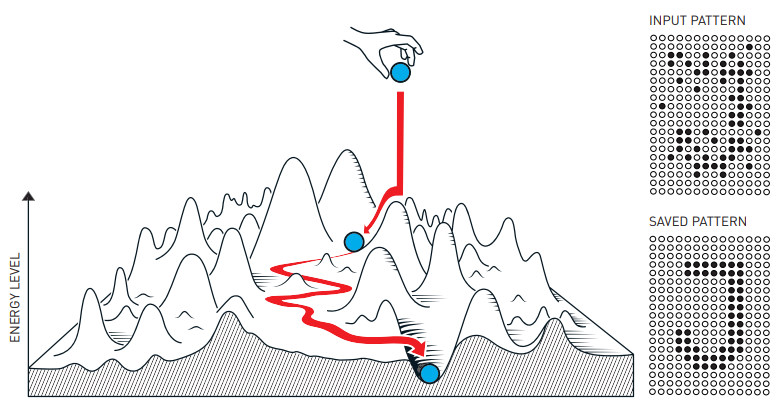

## ¿De Dónde Vienen?

Las redes de Hopfield modernas surgen de investigaciones teóricas y prácticas para superar las limitaciones de capacidad de las versiones originales propuestas por John Hopfield en 1982. Su desarrollo se basa en trabajos como:

El modelo de "Dense Associative Memory" propuesto por Dmitry Krotov y John Hopfield en 2016, que extiende la energía a términos polinómicos para aumentar la capacidad.
Extensiones en 2017 por Mete Demircigil et al., quienes formalizaron las memorias asociativas densas con interacciones de alto orden.
Aplicaciones prácticas en 2020 por Hubert Ramsauer et al., quienes integraron capas Hopfield en modelos de transformers (como en el paper "Hopfield Networks is All You Need"), conectándolas con mecanismos de atención modernos en deep learning.

El origen radica en la física estadística y la neurociencia computacional, inspiradas en modelos de spin-glass, pero adaptadas al contexto actual de IA para manejar big data y mejorar la escalabilidad.

## Funcionamiento de las Redes de Hopfield Modernas

La energía E en una red Hopfield moderna se define como una suma de términos polinómicos. Para un estado del sistema representado por un vector de spins ξ (donde cada componente es ±1 o continuo en versiones modernas), la energía es:


$$   E(\xi) = -\sum_{i=1}^{M} \left( \frac{1}{N} \sum_{j=1}^{N} \xi_j \mu_j^i \right)^p   $$


Donde:

*   M es el número de patrones memorizados (μ^i son los patrones).
*   N es el número de neuronas.
*   p es el grado del polinomio (p > 2 para versiones modernas; p=2 es la clásica).

Esta forma polinómica crea atractores más estables. La dinámica actualiza el estado ξ para minimizar E, típicamente usando una regla de actualización continua o discreta, similar a gradiente descendente.

In [4]:
# --- Funciones Centrales de Hopfield ---

# Función de energía polinómica
def energy(state, patterns, p_degree):
    N = state.shape[0]
    # Calcula las superposiciones (1/N * sum(xi * mu_i))
    overlaps = (1/N) * np.dot(patterns, state)
    # Término de energía polinómica
    return -np.sum(overlaps ** p_degree)

# Regla de actualización (similar al descenso de gradiente, usando tanh para valores continuos)
def update_state(state, patterns, p_degree, beta=1.0, num_neurons=None):
    if num_neurons is None:
        num_neurons = state.shape[0]

    # Calcula las superposiciones
    overlaps = (1/num_neurons) * np.dot(patterns, state)

    # Calcula el término del gradiente
    # Esto implica una suma sobre los patrones, donde cada patrón contribuye
    # al gradiente basado en su superposición y la derivada polinómica.
    # La derivada de x^p es p*x^(p-1)

    # Asegurar que las dimensiones coincidan para la difusión
    # 'overlaps' tiene forma (M,)
    # 'patterns' tiene forma (M, N)

    # (overlaps ** (p_degree - 1)) tendrá forma (M,)
    # Necesitamos multiplicar esto por 'patterns', lo que significa que (M,)
    # debe convertirse en (M, 1) para multiplicar correctamente con (M, N) antes de sumar a lo largo del eje 0

    # Manejo para p_degree - 1 = 0 (cuando p_degree = 1, aunque típicamente p >= 2)
    # np.power(0, 0) es 1. Esto es correcto para el caso p_degree=1, aunque p>2 para MHN.
    grad_term = np.power(overlaps, (p_degree - 1))[:, np.newaxis] * patterns
    grad = np.sum(p_degree * grad_term, axis=0)

    # Aplica tanh para obtener el nuevo estado, escalado por beta
    new_state = np.tanh(beta * grad)
    return new_state

# --- Función de Visualización Interactiva ---
def interactive_hopfield_simulation(N, M, p_degree, noise_level, num_iterations=100, beta=1.0):
    # Asegurar que N, M y p_degree sean enteros positivos y p_degree >= 2
    N = int(N) if N > 0 else 1
    M = int(M) if M > 0 else 1
    p_degree = int(p_degree) if p_degree >= 2 else 2 # p=2 es clásica, moderna > 2

    if N < 1 or M < 1:
        print("N y M deben ser enteros positivos.")
        return

    # Generar patrones aleatorios (±1.0 como float)
    patterns = np.random.choice([-1., 1.], size=(M, N))

    # Seleccionar un patrón para ser el objetivo de recuperación
    target_pattern = patterns[0].copy()

    # Crear estado inicial con ruido (continuo, similar al ejemplo original)
    initial_state = target_pattern.copy()
    noise = np.random.uniform(-noise_level, noise_level, size=N) # Ruido en un rango continuo
    initial_state += noise
    initial_state = np.clip(initial_state, -1., 1.) # Asegurar que los valores estén en [-1, 1]

    # Bucle de simulación
    current_state = initial_state.copy()
    energies = [energy(current_state, patterns, p_degree)]
    similarities = [np.dot(current_state, target_pattern) / N]

    for i in range(num_iterations):
        next_state = update_state(current_state, patterns, p_degree, beta, N)
        # Condición de convergencia: si el estado no cambia significativamente
        if np.allclose(next_state, current_state, atol=1e-6):
            # print(f"Convergido en la iteración {i+1}")
            break
        current_state = next_state
        energies.append(energy(current_state, patterns, p_degree))
        similarities.append(np.dot(current_state, target_pattern) / N)

    # Trazado
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Trazado de Energía
    axes[0].plot(energies, marker='o', linestyle='-', markersize=4)
    axes[0].set_title(f'Evolución de la Energía (p={p_degree})')
    axes[0].set_xlabel('Iteraciones')
    axes[0].set_ylabel('Energía E(ξ)')
    axes[0].grid(True)

    # Trazado de Similitud
    axes[1].plot(similarities, marker='o', linestyle='-', markersize=4, color='orange')
    axes[1].set_title('Similitud con el Patrón Original')
    axes[1].set_xlabel('Iteraciones')
    axes[1].set_ylabel('Similitud (producto punto / N)')
    axes[1].grid(True)
    axes[1].set_ylim(-1.1, 1.1)

    plt.tight_layout()
    plt.show()

    print(f"\nParámetros Finales:")
    print(f"  N (Neuronas): {N}")
    print(f"  M (Patrones): {M}")
    print(f"  p (Grado Polinómico): {p_degree}")
    print(f"  Nivel de Ruido Inicial: {noise_level*100:.0f}%")
    print(f"  Similitud final con el patrón original: {similarities[-1]:.3f}")


# --- Configuración de Widgets ---
N_slider = widgets.IntSlider(min=5, max=50, step=5, value=10, description='N (Neuronas):')
M_slider = widgets.IntSlider(min=1, max=20, step=1, value=5, description='M (Patrones):')
p_slider = widgets.IntSlider(min=2, max=5, step=1, value=3, description='p (Grado Polinómico):')
noise_slider = widgets.FloatSlider(min=0.0, max=0.5, step=0.05, value=0.2, description='Nivel de Ruido:')
iterations_slider = widgets.IntSlider(min=10, max=200, step=10, value=50, description='Max Iteraciones:')

# Vincula los widgets a la función de simulación
interactive_plot = widgets.interactive(interactive_hopfield_simulation,
                                       N=N_slider,
                                       M=M_slider,
                                       p_degree=p_slider,
                                       noise_level=noise_slider,
                                       num_iterations=iterations_slider,
                                       beta=1.0) # Beta fijo por simplicidad

# Muestra los widgets y la salida
display(interactive_plot)


interactive(children=(IntSlider(value=10, description='N (Neuronas):', max=50, min=5, step=5), IntSlider(value…

## ¿De qué manera recuerdan Patrones?

El "recuerdo" ocurre mediante la convergencia a un mínimo local de energía, que corresponde a un patrón memorizado. En las modernas:

* **Almacenamiento**: Los patrones se codifican en los pesos implícitos a través de la energía polinómica, permitiendo superposiciones densas sin colapso (a diferencia de las clásicas, donde muchos patrones causan "olvido catastrófico").
* **Recuperación**: Dado un patrón ruidoso o parcial, la red itera actualizando el estado hasta alcanzar un atractor (patrón memorizado). Los polinomios de alto grado permiten "recuerdos" más precisos porque los términos superiores suprimen estados espurios (falsos mínimos).
* **Mecanismo Matemático**: Los polinomios actúan como interacciones de muchos cuerpos (multi-spin), lo que expande el espacio de fase y permite memorizar exponencialmente más patrones. Por ejemplo, con $  p  $ creciente, la capacidad se acerca a la límite teórica de información.

En contextos de deep learning, se usan como capas de atención, donde la "memoria" se actualiza dinámicamente con softmax sobre similitudes exponenciales.

In [5]:
# --- Constants for Word Encoding ---
MAX_WORD_LENGTH = 6  # Maximum length of words to be encoded (all words will now be 6 chars)
BITS_PER_CHAR = 5    # Number of bits to represent each character (2^5 = 32, enough for 26 letters)
N_TOTAL_NEURONS = MAX_WORD_LENGTH * BITS_PER_CHAR

# --- Helper Functions for Word Encoding/Decoding ---
def char_to_binary_vector(char, bits_per_char=BITS_PER_CHAR):
    """
    Converts an uppercase letter to a binary vector (-1s and 1s).
    'A' -> 0, 'B' -> 1, ..., 'Z' -> 25
    The binary representation is then mapped to -1 and 1.
    """
    if not 'A' <= char.upper() <= 'Z':
        return np.full(bits_per_char, -1.0) # Treat non-alphabetic as blank/background

    char_code = ord(char.upper()) - ord('A') # 0 for A, 1 for B, etc.
    binary_repr = np.array([int(x) for x in bin(char_code)[2:].zfill(bits_per_char)], dtype=float)
    # Map 0 to -1, 1 to 1
    return 2 * binary_repr - 1 # Convert 0/1 to -1/1

def binary_vector_to_char(bin_vec, bits_per_char=BITS_PER_CHAR):
    """
    Converts a binary vector (-1s and 1s) back to an uppercase letter.
    """
    if len(bin_vec) != bits_per_char:
        return '?' # Incorrect vector length

    # Convert -1/1 to 0/1
    binary_01 = (bin_vec + 1) / 2
    # Round to nearest integer (0 or 1) and convert to string for int()
    binary_str = ''.join([str(int(round(x))) for x in binary_01])

    try:
        char_code = int(binary_str, 2)
        if 0 <= char_code <= 25: # A-Z
            return chr(ord('A') + char_code)
        else:
            return '?' # Out of A-Z range
    except ValueError:
        return '?' # Invalid binary string

def word_to_pattern_vector(word, max_length=MAX_WORD_LENGTH, bits_per_char=BITS_PER_CHAR):
    """
    Converts a word into a flattened binary vector of fixed length.
    Pads shorter words with 'blanks' (represented as all -1s for a character's bits).
    """
    vector = []
    for i in range(max_length):
        if i < len(word):
            vector.extend(char_to_binary_vector(word[i], bits_per_char))
        else:
            vector.extend(np.full(bits_per_char, -1.0)) # Blank character padding
    return np.array(vector, dtype=float)

def pattern_vector_to_word(vector, max_length=MAX_WORD_LENGTH, bits_per_char=BITS_PER_CHAR):
    """
    Converts a flattened binary vector back to a word.
    """
    word = []
    for i in range(max_length):
        char_vec = vector[i * bits_per_char : (i + 1) * bits_per_char]
        char = binary_vector_to_char(char_vec, bits_per_char)
        # Stop at the first 'blank' or invalid character, but include it if it's not a padding char
        if char == '?' and np.all(char_vec < 0.9): # Check for 'blank' padding (-1,-1,-1,-1,-1)
            break
        word.append(char)
    return "".join(word).replace('?', '') # Remove any remaining '?' that aren't actual padding


# --- Helper Functions for Sequence Processing (renamed/adapted) ---
def add_noise_to_vector(sequence_vector, noise_level, N):
    """
    Adds noise to a flattened sequence vector by flipping a percentage of bits.
    Ensures the array is float to avoid UFuncTypeError.
    """
    noisy_sequence = sequence_vector.astype(float).copy() # Ensure float type
    num_bits_to_flip = int(N * noise_level)
    if num_bits_to_flip > 0:
        flip_indices = np.random.choice(N, num_bits_to_flip, replace=False)
        noisy_sequence[flip_indices] *= -1.0 # Flip the bit value
    return noisy_sequence

def plot_text_pattern(ax, vector, title, color='b', max_length=MAX_WORD_LENGTH, bits_per_char=BITS_PER_CHAR):
    """
    Plots the binary representation of a word pattern and displays the decoded word.
    """
    word = pattern_vector_to_word(vector, max_length, bits_per_char)
    x = np.arange(len(vector))

    markerline, stemlines, baseline = ax.stem(x, vector)

    # Aplicar color correctamente (compatible con todas las versiones)
    plt.setp(markerline, color=color)
    plt.setp(stemlines, color=color)
    plt.setp(baseline, color='k')

    ax.set_ylim(-1.1, 1.1)
    ax.set_xticks(x[::bits_per_char] + bits_per_char/2 - 0.5)
    ax.set_xticklabels([f'Char {i+1}' for i in range(max_length)])
    ax.set_yticks([-1, 1])

    ax.set_title(f'{title}\n("{word}")')
    ax.set_xlabel('Posición del Bit')
    ax.set_ylabel('Valor (-1 o 1)')
    ax.grid(True)


# --- Hopfield Core Functions (adapted from previous cell) ---
def energy(state, patterns, p_degree):
    N = state.shape[0]
    overlaps = (1/N) * np.dot(patterns, state)
    return -np.sum(overlaps ** p_degree)

def update_state(state, patterns, p_degree, beta=1.0, num_neurons=None):
    if num_neurons is None:
        num_neurons = state.shape[0]

    overlaps = (1/num_neurons) * np.dot(patterns, state)

    grad_term = np.power(overlaps, (p_degree - 1))[:, np.newaxis] * patterns
    grad = np.sum(p_degree * grad_term, axis=0)

    new_state = np.tanh(beta * grad)
    return new_state


# --- Interactive Simulation for Word Patterns ---
def interactive_word_hopfield_simulation(p_degree, noise_level, selected_pattern_idx, num_iterations=50, beta=1.0):
    N = N_TOTAL_NEURONS # Global constant for total neurons

    # Define 20 word patterns (all 6 characters long)
    word_list = [
        "PYTHON", "MATRIX", "NEURAL", "SEARCH", "MEMORY",
        "SIGNAL", "TRAIN",  "ENGINE", "SYSTEM", "RANDOM",
        "VECTOR", "DEVICE", "OUTPUT", "INPUTS", "THRESH",
        "WEIGHT", "STATES", "FUTURE", "BRIGHT", "KERNEL"
    ]

    # Ensure all words are uppercase for consistent encoding
    word_list = [word.upper() for word in word_list]

    # Create patterns for the network
    patterns_list = [word_to_pattern_vector(word) for word in word_list]
    patterns = np.array(patterns_list, dtype=float) # Ensure float type
    M = patterns.shape[0]

    # Ensure selected_pattern_idx is valid
    if not (0 <= selected_pattern_idx < M):
        print(f"Índice de patrón inválido: {selected_pattern_idx}. Usando patrón 0.")
        selected_pattern_idx = 0

    target_pattern = patterns[selected_pattern_idx]
    target_word = word_list[selected_pattern_idx]

    # Create initial state with noise
    initial_state = add_noise_to_vector(target_pattern, noise_level, N)

    # Simulation loop
    current_state = initial_state.copy()
    states_history = [current_state.copy()]
    energies = [energy(current_state, patterns, p_degree)]
    similarities = [np.dot(current_state, target_pattern) / N]

    for i in range(num_iterations):
        next_state = update_state(current_state, patterns, p_degree, beta, N)
        if np.allclose(np.sign(next_state), np.sign(current_state), atol=1e-6):
            break
        current_state = next_state
        states_history.append(current_state.copy())
        energies.append(energy(current_state, patterns, p_degree))
        similarities.append(np.dot(current_state, target_pattern) / N)

    # Plotting
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 3) # Grid for subplots

    ax0 = fig.add_subplot(gs[0, 0])
    plot_text_pattern(ax0, target_pattern, f'Patrón Original', color='g')

    ax1 = fig.add_subplot(gs[0, 1])
    plot_text_pattern(ax1, initial_state, f'Entrada con Ruido ({noise_level*100:.0f}%)', color='orange')

    ax2 = fig.add_subplot(gs[0, 2])
    recovered_state = np.sign(states_history[-1]) # Discretize for display
    plot_text_pattern(ax2, recovered_state, f'Patrón Recuperado (Iter {len(states_history)-1})', color='purple')

    ax_energy = fig.add_subplot(gs[1, :2])
    ax_energy.plot(energies, marker='o', linestyle='-', markersize=4, color='red')
    ax_energy.set_title(f'Evolución de la Energía (p={p_degree})')
    ax_energy.set_xlabel('Iteraciones')
    ax_energy.set_ylabel('Energía E(ξ)')
    ax_energy.grid(True)

    ax_similarity = fig.add_subplot(gs[1, 2])
    ax_similarity.plot(similarities, marker='o', linestyle='-', markersize=4, color='blue')
    ax_similarity.set_title('Similitud con el Patrón Original')
    ax_similarity.set_xlabel('Iteraciones')
    ax_similarity.set_ylabel('Similitud (producto punto / N)')
    ax_similarity.set_ylim(-1.1, 1.1)
    ax_similarity.grid(True)

    plt.tight_layout()
    plt.show()

    final_recovered_word = pattern_vector_to_word(recovered_state)

    print(f"\nResultados de la Simulación:")
    print(f"  N (Neuronas/Bits totales): {N}")
    print(f"  M (Patrones Memorizados): {M}")
    print(f"  p (Grado Polinómico): {p_degree}")
    print(f"  Nivel de Ruido Inicial: {noise_level*100:.0f}%")
    print(f"  Palabra Original: '{target_word}'")
    print(f"  Palabra Recuperada: '{final_recovered_word}'")
    print(f"  Similitud final con el patrón original: {similarities[-1]:.3f}")
    if similarities[-1] > 0.95: # Arbitrary threshold for successful retrieval
        print("  Recuperación del patrón (palabra) exitosa.")
    else:
        print("  La recuperación del patrón (palabra) no fue completamente exitosa o el ruido fue demasiado alto.")

    # Display all memorized patterns as well for context
    fig_all_patterns, axs_all_patterns = plt.subplots(4, 5, figsize=(20, 12)) # 4 rows, 5 columns for 20 words
    fig_all_patterns.suptitle('Patrones de Palabras Memorizadas', fontsize=16)
    axs_all_patterns = axs_all_patterns.flatten()
    for i, pattern_vec in enumerate(patterns):
        plot_text_pattern(axs_all_patterns[i], pattern_vec, f'Patrón {i+1}', color='gray')
        axs_all_patterns[i].set_title(f'{word_list[i]}') # Display the word directly as title
        axs_all_patterns[i].set_xlabel('') # Clear x-label for this grid
        axs_all_patterns[i].set_ylabel('') # Clear y-label for this grid
        axs_all_patterns[i].set_xticks([]) # Remove x-axis ticks
        axs_all_patterns[i].set_yticks([]) # Remove y-axis ticks

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# --- Widgets Configuration ---
# N_TOTAL_NEURONS is fixed by MAX_WORD_LENGTH and BITS_PER_CHAR

p_slider = widgets.IntSlider(min=2, max=5, step=1, value=3, description='p (Grado Polinómico):')
noise_slider = widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.1, description='Nivel de Ruido (% de bits volteados):')

# Define the list of words for the dropdown
word_list_for_dropdown = [
    "PYTHON", "MATRIX", "NEURAL", "SEARCH", "MEMORY",
    "SIGNAL", "TRAIN",  "ENGINE", "SYSTEM", "RANDOM",
    "VECTOR", "DEVICE", "OUTPUT", "INPUTS", "THRESH",
    "WEIGHT", "STATES", "FUTURE", "BRIGHT", "KERNEL"
]

pattern_options = [(f'{word_list_for_dropdown[i]}', i) for i in range(len(word_list_for_dropdown))]

pattern_selector = widgets.Dropdown(
    options=pattern_options,
    value=0,
    description='Seleccionar Palabra:',
    disabled=False,
)
iterations_slider = widgets.IntSlider(min=50, max=200, step=10, value=100, description='Max Iteraciones:')


# Link widgets to the simulation function
interactive_plot_words = widgets.interactive(interactive_word_hopfield_simulation,
                                              p_degree=p_slider,
                                              noise_level=noise_slider,
                                              selected_pattern_idx=pattern_selector,
                                              num_iterations=iterations_slider,
                                              beta=1.0) # Beta fixed for simplicity

# Display widgets and output
display(interactive_plot_words)

interactive(children=(IntSlider(value=3, description='p (Grado Polinómico):', max=5, min=2), FloatSlider(value…

## Un pequeño repaso:

---

### ¿Para qué sirve la Función de Energía?

En física, los sistemas buscan naturalmente descansar en su estado de menor energía posible (como una pelota rodando hasta el fondo de un valle). En estas redes neuronales, la **Función de Energía** es simplemente una fórmula matemática que calcula un "puntaje" único para el estado actual de la red.

El único objetivo matemático de la red es: **minimizar ese puntaje**.

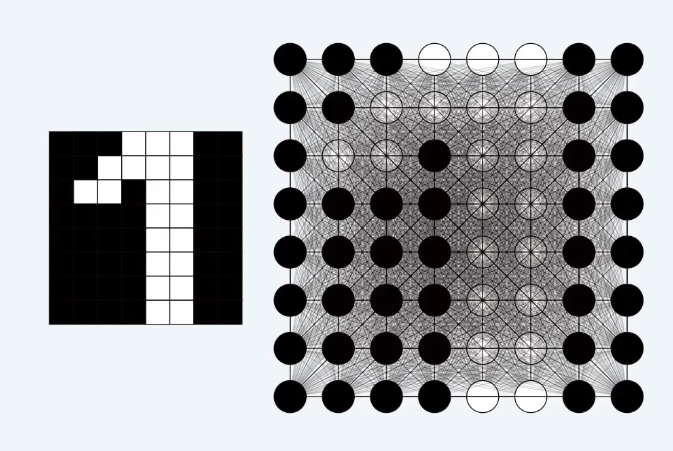


**¿Cómo cambia los estados de las neuronas?** Utiliza la función de energía como una brújula. Una neurona individual calculará: *"Si cambio mi estado de $+1$ a $-1$, ¿la energía total sube o baja?"*. Si la energía baja, la neurona cambia. Si sube, se queda igual. La red repite esto para cada neurona hasta que ningún cambio reduzca más la energía. En ese punto, la red se detiene: ha "recordado" un patrón.

Fundamentalmente, lo que hace que este tipo de redes neuronales "recuerde" son los pesos entre las neuronas. En cada iteración, el estado de cada neurona va cambiando según la función de energía para minimizar esta y, así, llegar al estado de equilibrio más cercano de entre los que están "tatuados" en los pesos.

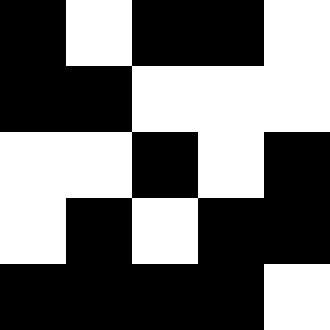


### La Red Hopfield Clásica (Interacciones de 2 cuerpos)

Esta es la ecuación de energía clásica de los años 80, que solo evalúa a las neuronas en pares:

$$E = -\frac{1}{2} \sum_{i,j} w_{ij} v_i v_j$$

**¿Qué significan los símbolos?**
* **$E$**: La Energía total de la red.
* **$v_i$ y $v_j$**: Los estados actuales de dos neuronas específicas, $i$ y $j$. En estos modelos, las neuronas son binarias, su estado es $+1$ (activa) o $-1$ (inactiva).
* **$w_{ij}$**: El "peso sináptico" o la fuerza de conexión entre la neurona $i$ y la neurona $j$. Este número es fijo y representa las memorias codificadas en la red.
* **$\sum_{i,j}$**: La sumatoria. La red observa cada par posible de neuronas, multiplica sus estados por su peso de conexión, y suma todo.

**La Regla de Actualización (Cómo cambian las neuronas):**
Para minimizar esta energía, la neurona $i$ mira a todos sus vecinos. Multiplica el estado de cada vecino ($v_j$) por el peso que comparten ($w_{ij}$) y los suma. Si el resultado es positivo, la neurona $i$ se convierte en $+1$. Si es negativo, se convierte en $-1$. Matemáticamente:

$$v_i \leftarrow \text{sign}\left(\sum_{j} w_{ij} v_j\right)$$

---


Se optimiza en varias dimensiones algo así, en el sentido en que hay varios minimos locales difusos (Fines ilustrativos, para esta los estados son discretos y de todo o nada):

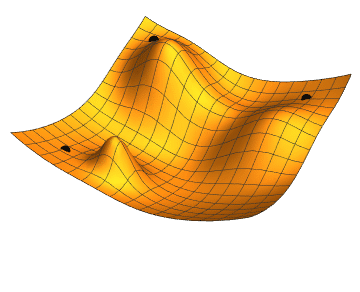

### Memorias Asociativas Densas (DAM / Redes Modernas)

Aquí se descarta la matriz de pesos clásica. En su lugar, la red compara su estado global completo con cada memoria almacenada y usa un amplificador matemático:

$$E = - \sum_{\mu=1}^{K} F(\xi^\mu \cdot v)$$

**¿Qué significan los símbolos?**
* **$E$**: La Energía total de la red.
* **$K$**: El número total de memorias almacenadas.
* **$\mu$**: El índice de una memoria específica (Memoria 1, Memoria 2... hasta $K$).
* **$\xi^\mu$**: La memoria almacenada en sí. Es un vector (una lista) de $+1$s y $-1$s que representa un patrón perfecto guardado.
* **$v$**: El estado actual de la red. También es un vector de $+1$s y $-1$s (por ejemplo, una imagen con ruido que quieres corregir).
* **$\xi^\mu \cdot v$**: El **producto punto**. Es una medida geométrica de similitud. Multiplica el vector de la memoria guardada por el vector del estado actual. Un número alto significa que son muy similares; un número bajo o negativo significa que son distintos.
* **$F$**: La función de activación no lineal (como $x^3$, $x^{20}$, o $e^x$). Este es el **amplificador mágico** que le da el poder a la red.

**La Regla de Actualización (Cómo cambian las neuronas):**
En lugar de mirar pares de neuronas, una DAM se actualiza comparando su estado actual $v$ con *todas* las memorias almacenadas $\xi^\mu$.

1. Calcula el producto punto ($\xi^\mu \cdot v$) para ver qué tan similar es el estado actual a cada memoria.
2. Pasa esos puntajes de similitud por la función $F$. Al ser una función exponencial o un polinomio muy grande, la memoria que sea ligeramente más parecida verá su puntaje multiplicado por millones, mientras que las demás se reducen a cero.
3. La red actualiza sus neuronas siendo atraída agresivamente hacia esa memoria ganadora.

En la matemática, la actualización es una suma ponderada de las memorias almacenadas, donde los pesos son esos puntajes amplificados (siendo $F'$ la derivada de la función $F$):

$$v_i \leftarrow \text{sign} \left( \sum_{\mu=1}^{K} F'(\xi^\mu \cdot v) \xi_i^\mu \right)$$

---


Sería algo así pero con valles mucho más pronunciados, donde cada valle es una memoria (Fines ilustrativos de nuevo, los estados siguen siendo discretos y de todo o nada):

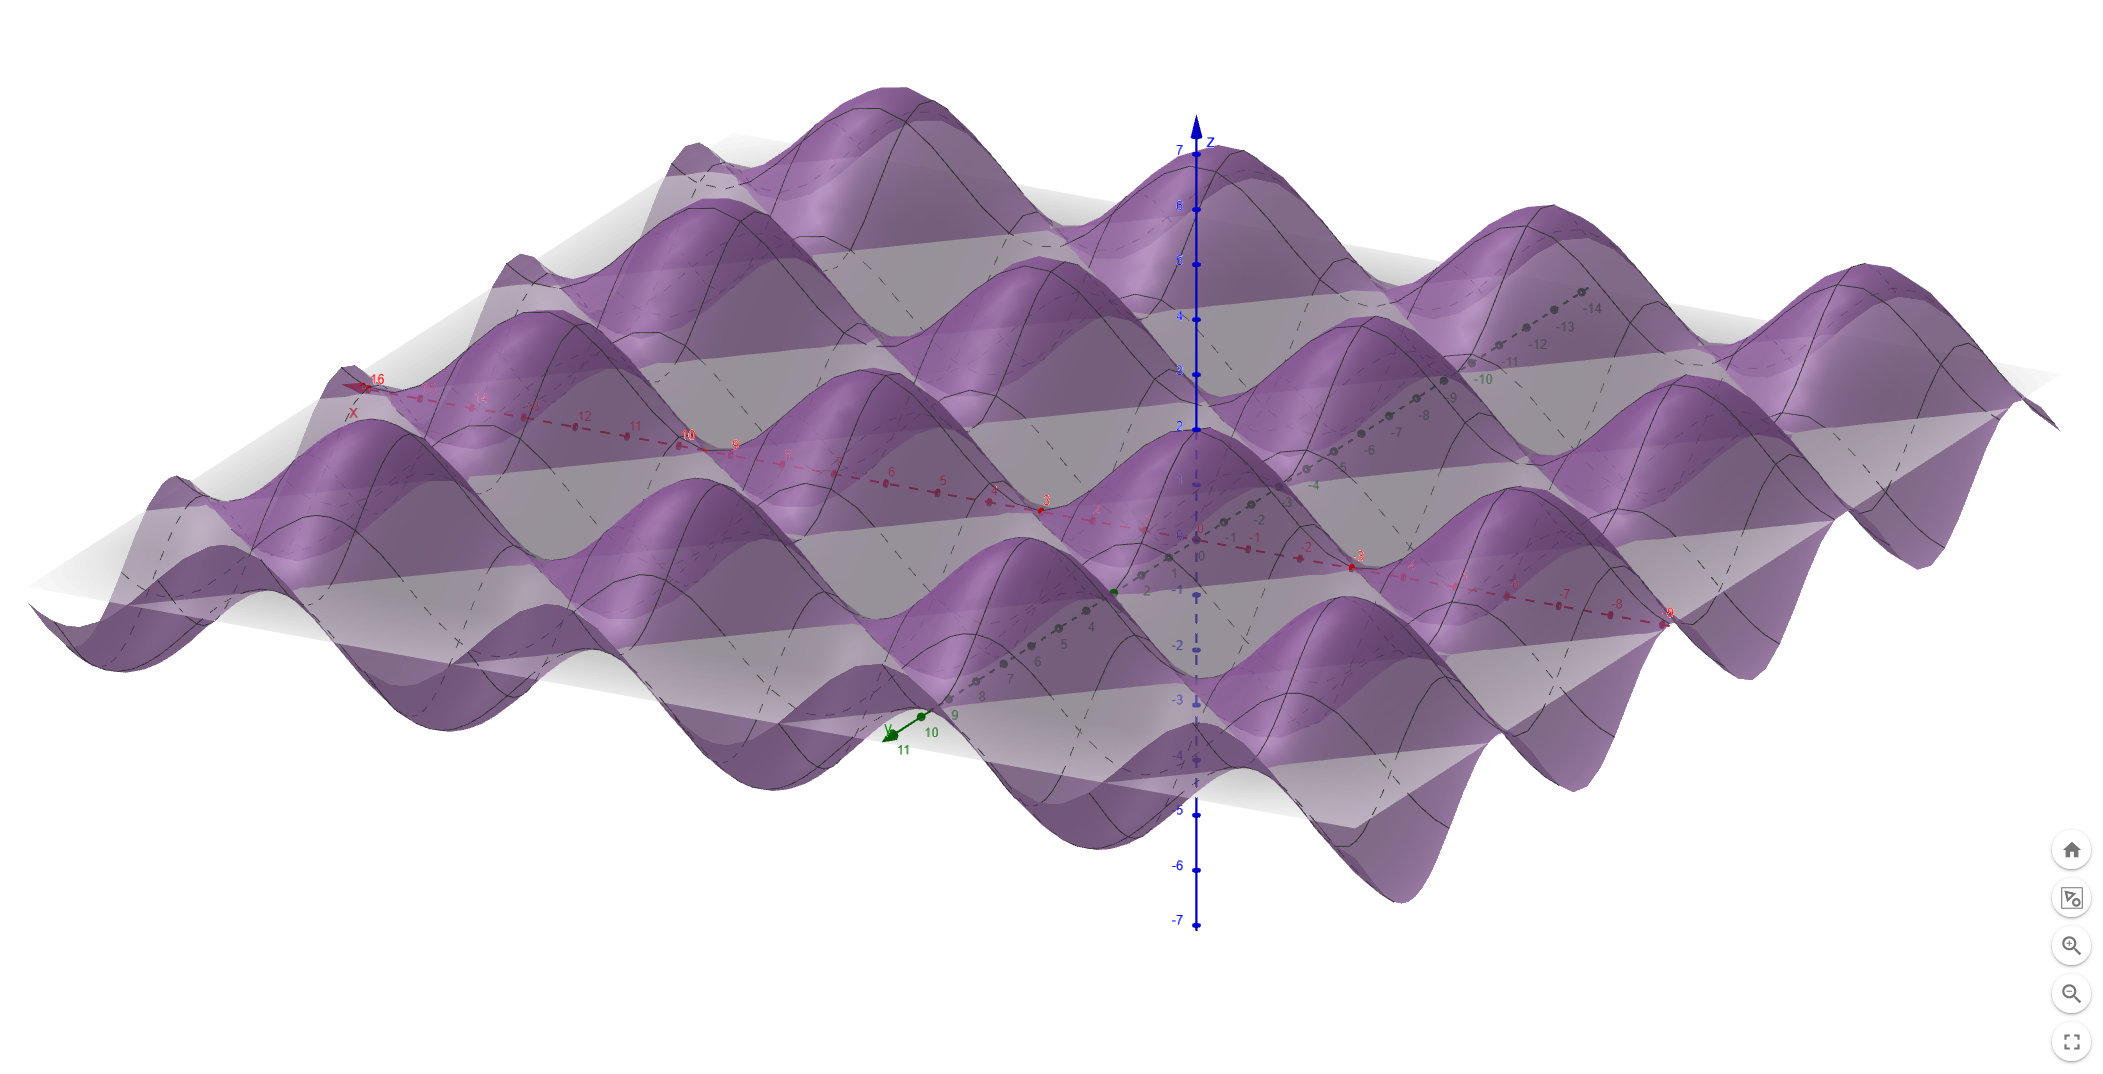

### La Evolución: De Estados Discretos a Continuos

Originalmente, las redes de Hopfield y las primeras DAM (2016) trabajaban con estados **discretos** ($+1$ y $-1$). Sin embargo, la investigación moderna (Ramsauer et al., 2020) dio el salto a los **estados continuos**, donde las neuronas pueden tomar cualquier valor real.

#### 1. ¿Cómo funciona la actualización continua?
En la versión continua, ya no obligamos a la neurona a elegir un bando con la función `sign()`. En su lugar, el nuevo estado de la red se calcula como un **promedio ponderado** de todas las memorias almacenadas:

$$v_{new} = \sum_{\mu=1}^{K} p_{\mu} \xi^{\mu}$$

Donde $p_{\mu}$ es una probabilidad (calculada usualmente con una función **Softmax**) que indica qué tan parecida es la memoria $\xi^{\mu}$ al estado actual.

#### 2. ¿En qué mejora esto a la red?

* **Diferenciabilidad y Entrenamiento:** Al ser funciones continuas y suaves, podemos usar **Backpropagation**. Esto permite que la red no solo "recuerde", sino que aprenda patrones complejos mediante descenso del gradiente, integrándose perfectamente en arquitecturas de Deep Learning.
* **Precisión Infinita:** En el modelo discreto, si un patrón está justo en el límite, la función signo puede dar un salto erróneo. En el modelo continuo, la red puede representar matices y combinaciones de memorias, lo que reduce drásticamente los errores de recuperación.
* **Conexión con los Transformers:** Este cambio es la pieza del rompecabezas que faltaba. Se ha demostrado matemáticamente que el mecanismo de **Atención** de los Transformers es, en realidad, una actualización de una Red de Hopfield Moderna continua.

### Comparativa Técnica: Ventajas, Desventajas y Limitaciones

El paso de las redes de Hopfield clásicas (1982) a las Memorias Asociativas Densas (DAM) representa una transición de interacciones lineales de dos cuerpos a interacciones de alto orden. Esto impacta directamente en la capacidad de almacenamiento y la estabilidad del sistema.

#### 1. DAM Discretas (Krotov & Hopfield, 2016)
*Utilizan funciones de activación polinómicas de alto grado y estados binarios ($+1, -1$).*

* **Ventajas:**
    * **Capacidad Super-lineal:** Superan el límite clásico de $0.14N$, permitiendo almacenar un número de patrones que escala con la potencia del polinomio.
    * **Robustez frente al ruido:** Al tener valles de energía más profundos, son extremadamente eficientes corrigiendo errores en datos corruptos sin mezclar memorias (evitan estados espurios).
    * **Realismo Biológico:** Mantienen la naturaleza discreta de los "spikes" neuronales, siendo útiles para modelar procesos cognitivos.
* **Desventajas y Limitaciones:**
    * **No Diferenciables:** El uso de la función `sign()` impide el uso de gradiente descendente (backpropagation), limitando su integración en redes de aprendizaje profundo estándar.
    * **Costo Computacional:** El cálculo de interacciones de muchos cuerpos aumenta la complejidad por cada patrón almacenado.

#### 2. DAM Continuas / Modern Hopfield Networks (Ramsauer et al., 2020)
*Utilizan funciones exponenciales y estados en el dominio de los números reales ($\mathbb{R}$).*

* **Ventajas:**
    * **Capacidad Exponencial:** Es el modelo con mayor almacenamiento teórico descubierto hasta la fecha, permitiendo recuperar patrones incluso con una fracción mínima de información inicial.
    * **Convergencia en un solo paso:** Gracias a la suavidad del paisaje de energía, la red suele encontrar el mínimo global de forma casi instantánea.
    * **Integración en Deep Learning:** Al ser totalmente diferenciables, permiten sustituir las capas de atención tradicionales de los Transformers, mejorando la gestión de memoria a largo plazo.
* **Desventajas y Limitaciones:**
    * **Consumo de VRAM:** A diferencia de la red clásica que "comprime" los datos en una matriz de pesos, estas redes suelen requerir mantener los patrones de referencia en memoria para compararlos (similar a un mecanismo de búsqueda).
    * **Inestabilidad Numérica:** Las funciones exponenciales son sensibles a valores extremos, lo que exige implementar técnicas como *Log-Sum-Exp* para evitar errores de precisión en hardware digital.

---

### Resumen Comparativo de Capacidades

| Modelo | Tipo de Interacción | Capacidad Teórica ($C$) | Naturaleza del Estado |
| :--- | :--- | :--- | :--- |
| **Hopfield Clásica** | Lineal (2-cuerpos) | $\approx 0.14 N$ | Discreto |
| **DAM (Krotov)** | Polinómica | $\approx N^{n-1}$ | Discreto |
| **Modern Hopfield** | Exponencial | $2^{N/2}$ | Continuo |


## Ejemplo interactivo sencillo con DAM discreta, no es una red, solo una demostración de los principios

In [ ]:
# 1. Carga de datos optimizada
if 'X_bin' not in locals():
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X_bin = np.where(mnist.data > 127, 1, -1)
    y_raw = mnist.target

# Almacenamos los 10 dígitos (Memorias)
memorias = np.array([X_bin[np.where(y_raw == str(i))[0][0]] for i in range(10)])

def demo_interactiva_fiel(digito_idx, ruido_pct, n_potencia):
    original = memorias[digito_idx]

    # Generar ruido
    np.random.seed(42)
    noisy = original.copy()
    mask = np.random.choice([True, False], size=784, p=[ruido_pct/100, 1-ruido_pct/100])
    noisy[mask] *= -1

    # --- Lógica DAM Fiel a la Teoría ---
    # 1. Producto punto normalizado (rango -1 a 1)
    # Esto es vital para que n_potencia tenga un sentido físico real
    similitudes = np.dot(memorias, noisy) / 784

    # 2. Función de activación (Derivada del potencial de Krotov)
    # En la teoría, se usa sign( sum( F'(similitud) * memoria ) )
    # Para n impares (preserva el signo)
    activacion = similitudes**(n_potencia - 1)

    # 3. Regla de actualización
    recuperado = np.sign(np.dot(activacion, memorias))

    # Visualización
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    imgs = [original, noisy, recuperado]
    titles = ["Original", f"Ruido {ruido_pct}%", f"DAM (n={n_potencia})"]
    for i in range(3):
        ax[i].imshow(imgs[i].reshape(28, 28), cmap='binary')
        ax[i].set_title(titles[i])
        ax[i].axis('off')
    plt.show()

interact(demo_interactiva_fiel,
         digito_idx=widgets.IntSlider(min=0, max=9, value=3, description='Dígito:'),
         ruido_pct=widgets.IntSlider(min=0, max=90, value=45, description='% Ruido:'),
         n_potencia=widgets.IntSlider(min=2, max=150, step=2, value=2, description='Potencia n:'))

interactive(children=(IntSlider(value=3, description='Dígito:', max=9), IntSlider(value=45, description='% Rui…

<function __main__.demo_interactiva_fiel(digito_idx, ruido_pct, n_potencia)>

### La Matemática detrás del éxito: ¿Por qué la normalización es clave?

Para que una **DAM Discreta** funcione según la teoría de Krotov & Hopfield, no basta con elevar la similitud a una potencia. El secreto reside en la gestión de los **valles de energía** y la estabilidad numérica.

#### 1. El problema de la escala
En una red de $N=784$ neuronas (como MNIST), el producto punto ($\xi^\mu \cdot v$) puede devolver valores muy grandes. Si elevamos un número como 200 a la potencia 30, el resultado supera los límites de cálculo de cualquier ordenador (`overflow`).

#### 2. La solución: Normalización en el rango $[-1, 1]$
Al dividir el producto punto por el número total de neuronas ($N$), convertimos la similitud en un porcentaje de coincidencia.
* Si la similitud es **0.9** (90% de coincidencia), al elevarlo a $n=50$, el valor sigue siendo significativo ($\approx 0.005$).
* Si la similitud es **0.5** (un patrón que se parece a medias), al elevarlo a $n=50$, el valor se convierte en $8.8 \times 10^{-16}$, es decir, **desaparece matemáticamente**.

#### 3. El Atractor de "Aguja"
Esta es la razón por la que las DAM son superiores:
* **Hopfield Clásica ($n=2$):** Los valles de energía son anchos como "boles". Si tienes muchas memorias, los boles se solapan y la red se confunde (estados espurios).
* **DAM ($n \gg 2$):** La función de potencia transforma los valles en "agujas" extremadamente estrechas y profundas. Solo si el patrón de entrada es muy similar a una memoria, "caerá" en la aguja. Esto permite que la capacidad de almacenamiento crezca masivamente sin que los recuerdos se interfieran entre sí.



---

### Resumen de la Lógica de Actualización

En el código dinámico, la actualización sigue este flujo:

1.  **Similitud Normalizada:** $S_\mu = \frac{1}{N} \sum_{i=1}^{N} \xi_i^\mu v_i$
2.  **Amplificación:** $Activación_\mu = (S_\mu)^{n-1}$
3.  **Consenso:** $v_{i}^{new} = \text{sign} \left( \sum_{\mu=1}^{K} Activación_\mu \cdot \xi_i^\mu \right)$

**Resultado:** A medida que aumentas $n$, la red se vuelve más "exigente". Deja de ver una mezcla de números y se enfoca únicamente en el patrón que tiene la mayor coincidencia, logrando una reconstrucción perfecta donde otros modelos fallan.

# Comparación: Hopfield clásica vs Hopfield moderna

En esta sección se comparan ambos modelos utilizando el mismo experimento:

1. Se almacenan varios patrones en ambas redes
2. Se introduce ruido en los patrones
3. Se intenta recuperar el patrón original
4. Se compara la precisión de recuperación

Esto permite visualizar claramente las diferencias entre ambos modelos.

##Crear patrones de prueba

Usaremos patrones simples tipo imágenes 8x8.

In [ ]:
# Crear algunos patrones simples

import numpy as np

# Letra A
A = np.array([
[0,0,1,1,1,1,0,0],
[0,1,0,0,0,0,1,0],
[1,0,0,0,0,0,0,1],
[1,1,1,1,1,1,1,1],
[1,0,0,0,0,0,0,1],
[1,0,0,0,0,0,0,1],
[1,0,0,0,0,0,0,1],
[0,0,0,0,0,0,0,0]
])

# Letra B
B = np.array([
[1,1,1,1,1,0,0,0],
[1,0,0,0,0,1,0,0],
[1,0,0,0,0,1,0,0],
[1,1,1,1,1,0,0,0],
[1,0,0,0,0,1,0,0],
[1,0,0,0,0,1,0,0],
[1,1,1,1,1,0,0,0],
[0,0,0,0,0,0,0,0]
])

# Letra C
C = np.array([
[0,1,1,1,1,1,0,0],
[1,0,0,0,0,0,1,0],
[1,0,0,0,0,0,0,0],
[1,0,0,0,0,0,0,0],
[1,0,0,0,0,0,0,0],
[1,0,0,0,0,0,1,0],
[0,1,1,1,1,1,0,0],
[0,0,0,0,0,0,0,0]
])

# Letra D
D = np.array([
[1,1,1,1,0,0,0,0],
[1,0,0,0,1,0,0,0],
[1,0,0,0,0,1,0,0],
[1,0,0,0,0,1,0,0],
[1,0,0,0,0,1,0,0],
[1,0,0,0,1,0,0,0],
[1,1,1,1,0,0,0,0],
[0,0,0,0,0,0,0,0]
])

patterns = [A,B,C,D]

## Visualizar patrones

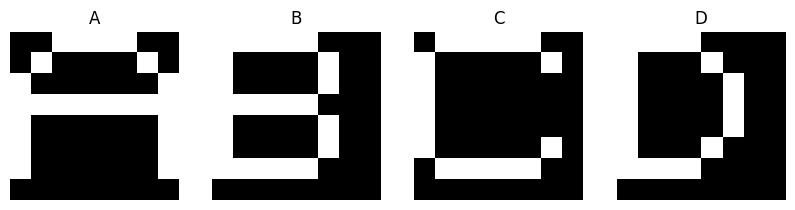

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(10,3))

letters = ["A","B","C","D"]

for i,p in enumerate(patterns):
    ax[i].imshow(p, cmap="gray")
    ax[i].set_title(letters[i])
    ax[i].axis("off")

plt.show()

## Implementación Hopfield clásica

In [ ]:
def train_hopfield(patterns):

    size = patterns[0].size
    W = np.zeros((size,size))

    for p in patterns:
        v = p.flatten()*2 - 1
        W += np.outer(v,v)

    np.fill_diagonal(W,0)

    return W

## Recuperación Hopfield clásica

In [ ]:
def recall_hopfield(W, pattern, steps=5):

    v = pattern.flatten()*2 - 1

    for _ in range(steps):
        v = np.sign(W @ v)

    return ((v+1)/2).reshape(pattern.shape)

##Simulación Hopfield moderna

Aquí usamos una **memoria basada en similitud tipo attention**, que es la idea central de Hopfield moderno.

In [ ]:
def modern_hopfield_recall(patterns, input_pattern):

    patterns_flat = np.array([p.flatten() for p in patterns])
    input_flat = input_pattern.flatten()

    similarities = patterns_flat @ input_flat

    weights = np.exp(similarities)
    weights /= np.sum(weights)

    recovered = np.sum(weights[:,None] * patterns_flat, axis=0)

    recovered = (recovered > 0.5).astype(int)

    return recovered.reshape(input_pattern.shape)

##Entrenar red clásica

In [ ]:
W = train_hopfield(patterns)

##Crear ruido

In [ ]:
def add_noise(pattern, noise_level=0.3):

    noisy = pattern.copy()
    flip = np.random.rand(*pattern.shape) < noise_level

    noisy[flip] = 1 - noisy[flip]

    return noisy

##Comparación directa
Aquí se ve la comparación real.

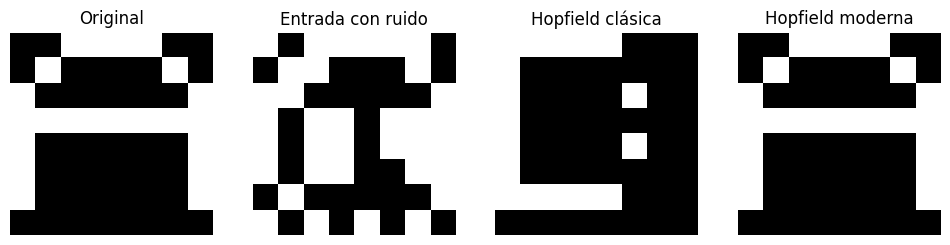

In [ ]:
original = patterns[0]

noisy = add_noise(original,0.35)

classic_result = recall_hopfield(W,noisy)

modern_result = modern_hopfield_recall(patterns,noisy)

fig, ax = plt.subplots(1,4, figsize=(12,3))

ax[0].imshow(original,cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(noisy,cmap='gray')
ax[1].set_title("Entrada con ruido")

ax[2].imshow(classic_result,cmap='gray')
ax[2].set_title("Hopfield clásica")

ax[3].imshow(modern_result,cmap='gray')
ax[3].set_title("Hopfield moderna")

for a in ax:
    a.axis("off")

plt.show()

##Medir precisión

In [ ]:
def accuracy(a,b):
    return np.mean(a==b)

acc_classic = accuracy(original, classic_result)
acc_modern = accuracy(original, modern_result)

print("Precisión Hopfield clásica:",acc_classic)
print("Precisión Hopfield moderna:",acc_modern)

Precisión Hopfield clásica: 0.640625
Precisión Hopfield moderna: 1.0


##Gráfica de comparación

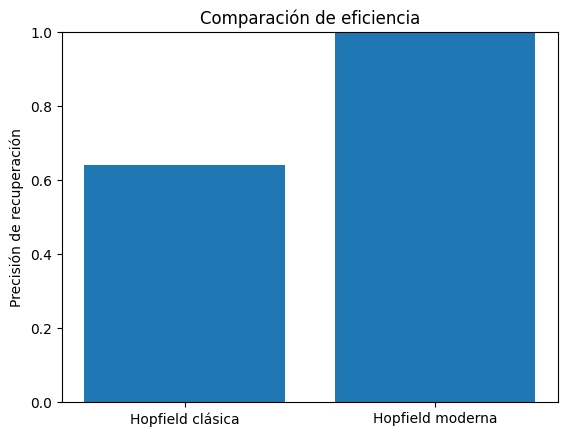

In [ ]:
labels = ["Hopfield clásica","Hopfield moderna"]
values = [acc_classic, acc_modern]

plt.bar(labels,values)
plt.ylim(0,1)

plt.ylabel("Precisión de recuperación")
plt.title("Comparación de eficiencia")

plt.show()

## Conclusión de la comparación

En el experimento se puede observar que:

- Ambas redes intentan recuperar el patrón original a partir de una entrada con ruido.
- La red de Hopfield clásica puede fallar si el ruido es alto o si hay demasiados patrones almacenados.
- La red de Hopfield moderna tiene una recuperación más robusta debido a su mecanismo basado en similitud.

Esto demuestra cómo las redes modernas mejoran significativamente la capacidad de memoria y la estabilidad de recuperación.

# **Recursos Adicionales**

## Artículos científicos fundamentales

Estos artículos presentan las bases teóricas del modelo original y su reformulación moderna.

• Hopfield, J. J. (1982)  
Neural networks and physical systems with emergent collective computational abilities  
https://www.pnas.org/doi/10.1073/pnas.79.8.2554

Este artículo introduce el modelo original de redes de Hopfield y el concepto de memoria asociativa basada en mínimos de energía.

---

• Krotov, D., & Hopfield, J. (2020)  
Hopfield Networks is All You Need  
https://arxiv.org/abs/2008.02217

Este trabajo propone la reformulación moderna de las redes de Hopfield utilizando una función de energía basada en log-sum-exp y demuestra su conexión con mecanismos de atención.

---

• Ramsauer, H. et al. (2021)  
Hopfield Networks is All You Need (versión ampliada)  
https://arxiv.org/abs/2008.02217

Describe cómo integrar redes de Hopfield modernas dentro de arquitecturas de deep learning.

## Implementaciones en código abierto

Existen varias implementaciones disponibles que permiten experimentar con redes de Hopfield modernas.

• Implementación de Hopfield moderna en PyTorch  
https://github.com/ml-jku/hopfield-layers

Repositorio oficial con implementación basada en el paper de redes de Hopfield modernas.

---

• Implementación educativa de Hopfield Networks en Python  
https://github.com/felix-andreas/hopfieldnetwork

Incluye ejemplos simples y visuales del funcionamiento de redes de Hopfield clásicas.

---

• Ejemplos de notebooks sobre Hopfield Networks  
https://github.com/topics/hopfield-network

# **Bibliografía**
---


> <a id="cite1"></a>**[1]** D. Krotov and J. J. Hopfield, ["Dense associative memory for pattern recognition"](https://proceedings.neurips.cc/paper_files/paper/2016/file/eaae339c4d89fc102edd9dbdb6a28915-Paper.pdf), in Advances in Neural Information Processing Systems 29, pp. 1172-1180, 2016.

> <a id="cite2"></a>**[2]** Layerwise Lectures, "Hopfield network: How are memories stored in neural networks? [Nobel Prize in Physics 2024] #SoME2," YouTube, Aug. 15, 2022. [Online]. Available: https://www.youtube.com/watch?v=piF6D6CQxUw. [Accessed: Mar. 2, 2026].

> <a id="cite3"></a>**[3]** MITCBMM, "Dense Associative Memory in Machine Learning," YouTube, Feb. 5, 2024. [Online]. Available: https://www.youtube.com/watch?v=K3JOQVflvyM. [Accessed: Mar. 2, 2026].

> <a id="cite4"></a>**[4]** H. Ramsauer et al., "Hopfield Networks is All You Need," arXiv preprint arXiv:2008.02217, 2020. [Online]. Available: https://arxiv.org/abs/2008.02217. [Accessed: Mar. 2, 2026].


> <a id="cite5"></a>**[5]** J. J. Hopfield, "Hopfield Networks and Physical Systems with Emergent Collective Computational Abilities," *Proceedings of the National Academy of Sciences*, vol. 79, no. 8, pp. 2554–2558, 1982. [Online]. Available: https://www.pnas.org/doi/10.1073/pnas.79.8.2554. [Accessed: Mar. 2, 2026].

> <a id="cite6"></a>**[6]** T. M. K. Baumann, K. Kossen, and D. Krotov, "Modern Hopfield Networks and Attention for Immune Repertoire Classification," *Advances in Neural Information Processing Systems (NeurIPS)*, vol. 33, 2020. [Online]. Available: https://arxiv.org/abs/2007.13505. [Accessed: Mar. 2, 2026].

> <a id="cite7"></a>**[7]** A. Kirsanov, "A Brain-Inspired Algorithm For Memory", YouTube, Jul. 2, 2024. [Online]. Available: https://youtu.be/1WPJdAW-sFo. [Accessed: Mar. 4, 2026].

> <a id="cite7"></a>**[8]** J. J. Hopfield, "Neurons with graded response have collective computational properties like those of two-state neurons," Proceedings of the National Academy of Sciences, vol. 81, no. 10, pp. 3088–3092, 1984. [Online]. Available: https://www.pnas.org/doi/10.1073/pnas.81.10.3088
. [Accessed: Mar. 5, 2026].

> <a id="cite7"></a>**[9]** D. J. Amit, H. Gutfreund, and H. Sompolinsky, "Spin-glass models of neural networks," Physical Review A, vol. 32, no. 2, pp. 1007–1018, 1985. [Online]. Available: https://doi.org/10.1103/PhysRevA.32.1007
. [Accessed: Mar. 5, 2026].

> <a id="cite7"></a>**[10]** . Hertz, A. Krogh, and R. G. Palmer, Introduction to the Theory of Neural Computation. Redwood City, CA, USA: Addison-Wesley, 1991.

> <a id="cite7"></a>**[11]** V. Folli, M. Leonetti, and G. Ruocco, "On the Maximum Storage Capacity of the Hopfield Model," Frontiers in Computational Neuroscience, vol. 10, article 144, 2017. [Online]. Available: https://doi.org/10.3389/fncom.2016.00144
. [Accessed: Mar. 5, 2026].

> <a id="cite7"></a>**[12]** J. J. Hopfield and D. W. Tank, "Neural computation of decisions in optimization problems," Biological Cybernetics, vol. 52, no. 3, pp. 141–152, 1985. [Online]. Available: https://doi.org/10.1007/BF00339943
. [Accessed: Mar. 5, 2026].

